In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE = '/content/drive/MyDrive/Phishing_Detection_Project'

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

Mounted at /content/drive


In [2]:
model = joblib.load(f"{BASE}/models/best_model.pkl")
scaler = joblib.load(f"{BASE}/models/scaler.pkl")

df = pd.read_csv(f"{BASE}/data/processed/engineered_data.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1].replace(-1,0)

print("Loaded successfully")

Loaded successfully


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = scaler.transform(X_test)

In [4]:
y_pred = model.predict(X_test)

print("Prediction complete")

Prediction complete


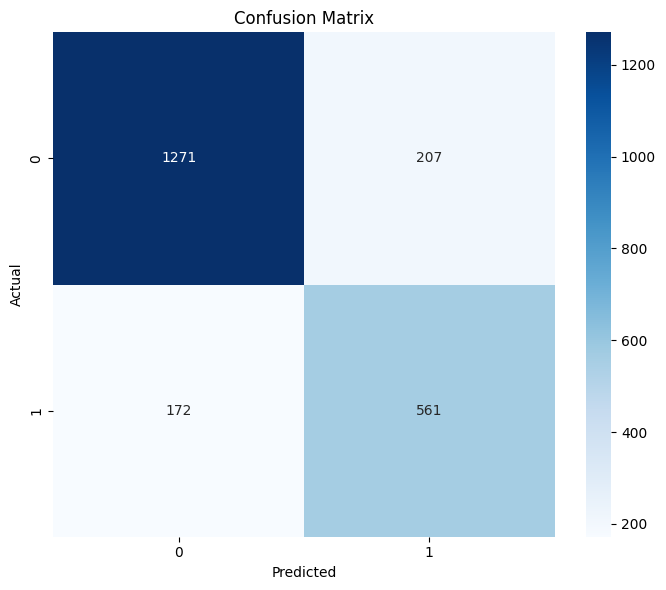

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/confusion_matrix.png", dpi=150)
plt.show()

In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1478
           1       0.73      0.77      0.75       733

    accuracy                           0.83      2211
   macro avg       0.81      0.81      0.81      2211
weighted avg       0.83      0.83      0.83      2211



In [7]:
results = pd.read_csv(f"{BASE}/outputs/model_results.csv")
print(results)

                 Model  Accuracy (%)
0  Logistic Regression         80.37
1        Random Forest         82.86
2                  SVM         80.78
3                  KNN         80.82


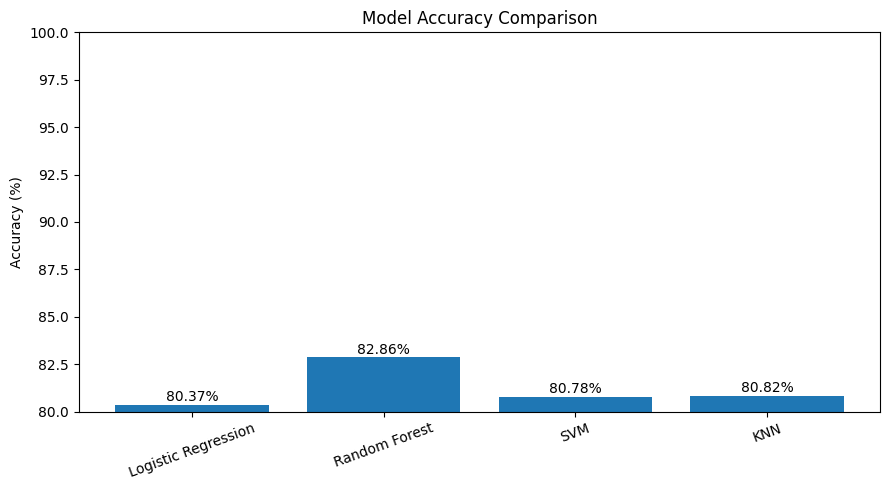

In [8]:
plt.figure(figsize=(9,5))

plt.bar(results['Model'], results['Accuracy (%)'])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(80,100)

for i,v in enumerate(results['Accuracy (%)']):
    plt.text(i, v+0.2, str(v)+"%", ha='center')

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(f"{BASE}/outputs/model_comparison.png", dpi=150)
plt.show()

In [9]:
feature_names = X.columns.tolist()

def predict_website(features):
    arr = np.array(features).reshape(1,-1)
    arr = scaler.transform(arr)

    pred = model.predict(arr)[0]

    if pred == 1:
        print("Legitimate Website")
    else:
        print("Phishing Website")

In [10]:
sample = [1]*len(feature_names)

predict_website(sample)

Phishing Website


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
obs = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20]
})

obs.to_csv(f"{BASE}/outputs/observation_table.csv", index=False)

print(obs)

    Actual  Predicted
0        1          1
1        1          0
2        0          0
3        0          0
4        0          0
5        1          0
6        0          0
7        1          1
8        0          0
9        0          0
10       1          1
11       1          1
12       1          1
13       1          0
14       1          0
15       1          1
16       1          1
17       0          1
18       0          0
19       0          0


In [12]:
print("PROJECT COMPLETED SUCCESSFULLY")

PROJECT COMPLETED SUCCESSFULLY
